In [2]:
import json
import tiktoken

In [3]:
infra_path = "../../infra/"
json_path = f"{infra_path}json/"
cuad_json = f"{infra_path}CUAD_v1/CUAD_v1.json"
cuad_json, json_path

('../../infra/CUAD_v1/CUAD_v1.json', '../../infra/json/')

In [4]:
with open(cuad_json, "r") as f:
    cuad_data = json.load(f)

In [5]:
len(cuad_data['data'])

510

In [6]:
from pydantic import BaseModel, Field
from typing import List, Optional
from pathlib import Path
import re

class Node(BaseModel):
    id: str
    text: str
    relationsCount: int = 0

class Edge(BaseModel):
    source: str
    target: str
    type: str
    score: Optional[float] = None
    ref_label: Optional[str] = None
    ref_value: Optional[str] = None

class Graph(BaseModel):
    nodes: List[Node]
    edges: List[Edge]

class Config:
  CUAD_PDF_DIR = Path("../infra/CUAD_v1/full_contract_pdf")
  CUAD_DOC_DIR = Path("../infra/CUAD_v1/full_contract_docx")
  EDITED_PDF_DIR = Path("../infra/edited_pdfs")
  EDITED_DOC_DIR = Path("../infra/edited_docs")
  REFERENCE_PATTERNS = [
    ("section", re.compile(r'\b[Ss]ection\s+(\d+(?:\.\d+)*)\b')),
    ("article", re.compile(r'\b[Aa]rticle\s+(\d+(?:\.\d+)*)\b')),
    ("schedule", re.compile(r'\b[Ss]chedule\s+([A-Za-z]|\d+(?:\.\d+)*)\b')),
    ("annex",    re.compile(r'\b[Aa]nnex\s+([A-Za-z]|\d+(?:\.\d+)*)\b')),
    ("appendix", re.compile(r'\b[Aa]ppendix\s+([A-Za-z]|\d+(?:\.\d+)*)\b')),
  ]
    
  TYPE_PRIORITY = {
    "precedence": 5,
    "scope": 4,
    "deontic": 3,
    "numeric": 2,
    "definition": 2,
    "other": 1
  }

#### Extract context

In [7]:
new_json_only_context = []

COST_INPUT_PER_MILLION = 0.40  # millon tokens
COST_OUTPUT_PER_MILLION = 1.60  # millon tokens
cost_input_model_per_token = (COST_INPUT_PER_MILLION / 1_000_000)
cost_output_model_per_token = (COST_OUTPUT_PER_MILLION / 1_000_000)
enc = tiktoken.encoding_for_model("gpt-4.1-mini")

index = 1
for item in cuad_data['data']:
    title = item['title']
    context = item['paragraphs'][0]['context']
    number_tokens = len(enc.encode(context))

    new_json_only_context.append({
        "id": f"CUAD_{index}",
        "title": title,
        "context": context,
        'total_number_tokens': number_tokens,
        'cost_document_input': ((number_tokens / 1_000_000) * COST_INPUT_PER_MILLION),
        'cost_document_output': ((number_tokens / 1_000_000) * COST_OUTPUT_PER_MILLION)
    })

    index += 1

In [8]:
document_output_path = f"{json_path}rerank/context.json" 

with open(document_output_path, "w") as f:
    json.dump(new_json_only_context, f, indent=4)

In [9]:
INPUT_PATH = f"{json_path}/rerank/context.json"
OUTPUT_PATH = f"{json_path}/rerank/paragraphs.json"

MAX_DOCS = 1
threshold_tokens = 12000

def split_into_paragraphs(text: str):
    text = text.replace("\r\n", "\n").strip()
    parts = re.split(r"\n\s*\n+", text)

    out = []
    for part in parts:
        clean = " ".join(part.split())
        if clean:
            out.append(clean)

    if out:
        return out

    clean = " ".join(text.split())
    return [clean] if clean else []

with open(INPUT_PATH, "r", encoding="utf-8") as f:
    docs = json.load(f)

candidate_docs = docs

print(len(candidate_docs), "\n")

selected = []
for i, doc in enumerate(candidate_docs, start=1):
    context = doc.get("context", "")
    total_tokens_doc = len(enc.encode(context))

    if total_tokens_doc >= threshold_tokens:
        selected.append(doc)

selected = sorted(selected, key=lambda d: len(enc.encode(d.get("context", ""))), reverse=False)

print(len(selected), "\n")

stage1 = []

for doc in selected[:MAX_DOCS]:
    paragraphs = []

    for i, p_text in enumerate(split_into_paragraphs(doc.get("context", "")), start=1):
        n_tokens = len(enc.encode(p_text))

        paragraphs.append(
            {
                "idx": f"IDX{i}",
                "text": p_text,
                "number_tokens": n_tokens,
                "cost_document_input": (n_tokens / 1_000_000) * cost_input_model_per_token,
                "cost_document_output": (n_tokens / 1_000_000) * cost_output_model_per_token,
            }
        )

    stage1.append(
        {
            "doc_id": doc.get("id"),
            "num_paragraphs": len(paragraphs),
            "total_number_tokens": sum(p["number_tokens"] for p in paragraphs),
            "cost_document_input": sum(p["cost_document_input"] for p in paragraphs),
            "paragraphs": paragraphs,
        }
    )

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(stage1, f, indent=2, ensure_ascii=False)

510 

148 



#### Create Graph

In [10]:
from sentence_transformers import SentenceTransformer, util

def generate_graph_data(paragraphs_data: list) -> Graph:
    model = SentenceTransformer('all-MiniLM-L6-v2')
    nodes: List[Node] = []
    edges: List[Edge] = []
    
    for p in paragraphs_data:
        node = Node(
            id=str(p.get("idx")),
            text=p.get("text", "").strip(),
            relationsCount=0,
        )
        nodes.append(node)
    
    for i in range(len(nodes)):
        current_text = nodes[i].text
        for ref_type, pattern in Config.REFERENCE_PATTERNS:
            matches = pattern.finditer(current_text)
            for match in matches:
                ref_id = match.group(1)
                for target_node in nodes:
                    if target_node.id != nodes[i].id and target_node.text.startswith(ref_id):
                        edges.append(Edge(
                            source=nodes[i].id, 
                            target=target_node.id, 
                            type="reference",
                            ref_label=ref_type,
                            ref_value=ref_id
                        ))

    if nodes:
        embeddings = model.encode([n.text for n in nodes], convert_to_tensor=True)
        cosine_scores = util.cos_sim(embeddings, embeddings)

        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                score = float(cosine_scores[i][j])
                if score > 0.8:
                    edges.append(Edge(
                        source=nodes[i].id, 
                        target=nodes[j].id, 
                        type="semantic_similarity", 
                        score=score
                    ))

    relations_map = {}
    for edge in edges:
        relations_map[edge.source] = relations_map.get(edge.source, 0) + 1
        relations_map[edge.target] = relations_map.get(edge.target, 0) + 1
    
    for node in nodes:
        node.relationsCount = relations_map.get(node.id, 0)

    return Graph(nodes=nodes, edges=edges)

/home/luis/miniconda3/envs/doc/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
graph = generate_graph_data(stage1[0]["paragraphs"])
graph

Graph(nodes=[Node(id='IDX1', text='1 EXHIBIT 10.17 [E.PIPHANY Logo]', relationsCount=0), Node(id='IDX2', text='OUTSOURCING AGREEMENT', relationsCount=0), Node(id='IDX3', text='This ASP and Outsourcing Agreement ("Agreement") is entered into as of this 31 day of July, 2000 ("Effective Date") by and between E.PIPHANY, INC., a Delaware corporation ("E.piphany"), whose principal place of business 1900 South Norfolk Street, Suite 310, San Mateo, California 94403 and HIGH SPEED NET SOLUTIONS, INC. ("HSNS"), whose principal place of business is 434 Fayetteville Street, St. Suite 2120, Raleigh, NC 27601.', relationsCount=0), Node(id='IDX4', text='1. LICENSE', relationsCount=0), Node(id='IDX5', text='1.1 OUTSOURCING LICENSE. Subject to the terms of this Agreement and Scope of Use and only within the Market and Territory, E.piphany grants HSNS a nonexclusive, nontransferable, non-sublicensable right to (i) use and combine the Application with the Outsourcing Application and other software produc

#### "Query-like object”

Reranker Concept for Graph-Based Contradiction Generation

In this scenario there is no external query. The "query-like object" is the target node where the contradiction will be inserted.

Instead of asking:

> "What paragraphs are most relevant to answer a user question?"

The system asks:

> "Given node ``Idx5``, which nodes in the graph are the most relevant to condition, restrict, or contextualize a contradiction that will be inserted into ``Idx5``?"

This changes the logic of reranking.

The reranker in this pipeline is better described as a:

- node-to-node relevance ranker
or
- context selector for contradiction generation

Inputs:
- target node (``v_target``)
- candidate neighbors N(``v_target``) or nodes within 1–2 hops
- the local subgraph

Output:
- ranking of nodes most relevant to the target node

No textual query is used. The target node acts as the semantic anchor.

--------------------------------------------------

Pipeline

1. The document is divided into paragraphs.

2. A graph is constructed where:
   - nodes = paragraphs
   - edges = references or semantic similarity

3. A target node ``v_target`` is selected.

4. Candidate nodes related to ``v_target`` are retrieved.
   For example:
   - direct neighbors
   - semantic neighbors
   - reference links
   Example size: top-5 candidates.

5. A reranker orders the candidates based on relevance to ``v_target``.

6. The system selects the top-3 nodes.

7. The contradiction generation module receives:
   - target paragraph
   - top-3 contextual nodes

8. A contradiction is generated for the target node.

9. The modified paragraph is inserted back into the document.

10. The resulting document becomes part of the contradiction dataset.

--------------------------------------------------

Meaning of "Relevance"

Relevance here does not mean answering a question. Instead it means identifying nodes that influence the logical interpretation of the target node.

Relevant nodes may include:

- paragraphs that define terms used in the target node
- paragraphs that introduce exceptions
- paragraphs that establish precedence rules
- paragraphs that reference the target node
- paragraphs that depend logically on the target node

--------------------------------------------------

Retrieve vs Rerank

Retrieve step:
The goal is recall. We gather a reasonably large set of potentially useful nodes.

Example sources:
- graph neighbors
- semantic similarity edges
- reference edges

Rerank step:
The goal is precision. The system orders nodes according to how strongly they interact with the target node.

--------------------------------------------------

Signals for Node Relevance

Possible signals include:

1. Explicit references
If a node references another node, this relationship is highly informative.

Example patterns:
- "subject to Section 4.2"
- "as defined in Section 1"
- "except as provided in Clause 9"

2. Semantic similarity
Embedding similarity between nodes.

3. Graph structure
Number of edges and connectivity.

4. Graph distance
Nodes closer in the graph may be more relevant.

5. Legal role of the paragraph
Some paragraphs are structurally more important.

Examples:
- definitions
- obligations
- exceptions
- scope restrictions

6. Shared entities or terminology
Overlap in legal entities, dates, numbers, or defined terms.

--------------------------------------------------

Conceptual Ranking Function

$$
\text{score}(\text{candidate} \mid \text{target}) = \alpha \cdot \text{semantic\_similarity}(\text{target}, \text{candidate}) + \beta \cdot \text{reference\_strength}(\text{target}, \text{candidate}) + \gamma \cdot \text{legal\_interaction}(\text{target}, \text{candidate}) + \delta \cdot \text{graph\_distance}(\text{target}, \text{candidate}) + \varepsilon \cdot \text{entity\_overlap}(\text{target}, \text{candidate})
$$

--------------------------------------------------

Example Scenario

Target node: ``Idx5``

Candidate nodes retrieved:
Idx1, Idx2, Idx3, Idx4, Idx6

After reranking:

1. Idx3
2. Idx2
3. Idx6
4. Idx4
5. Idx1

Top-3 context nodes:
Idx3, Idx2, Idx6

The contradiction generator uses:

- text of ``Idx5``
- context from Idx3, Idx2, Idx6

to generate a coherent but contradictory modification of ``Idx5``.

--------------------------------------------------

Module Structure

- Module 1: Candidate Retrieval
   - Input: target node
   - Output: set of candidate nodes

- Module 2: Candidate Reranking
   - Input: target node + candidate nodes
   - Output: ranked nodes

- Module 3: Contradiction Generation
   - Input: target node + top context nodes
   - Output: contradictory paragraph

- Module 4: Document Reconstruction 
   - Insert modified paragraph into the original document.

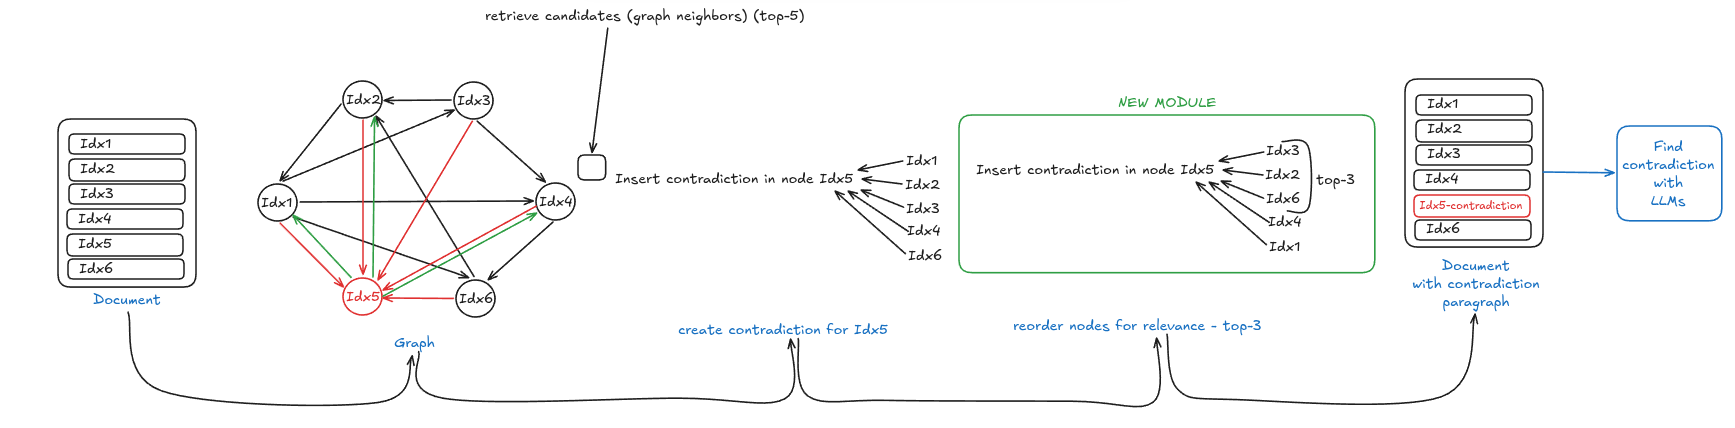

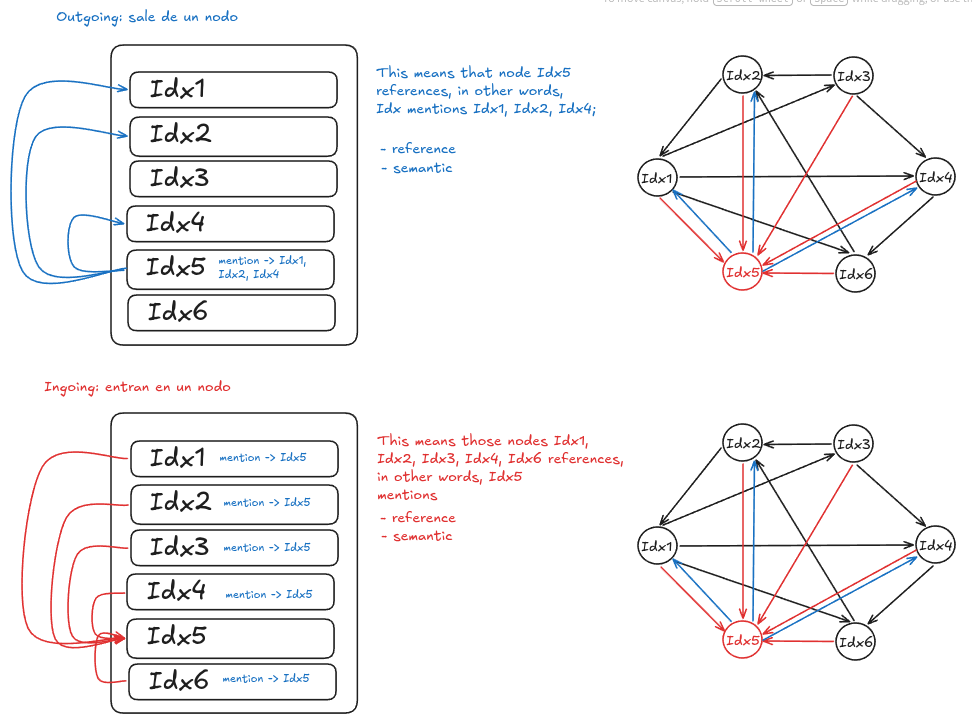

In [18]:
max_node = max(graph.nodes, key=lambda n: n.relationsCount)
print("Node with more relations:")
print("ID:", max_node.id)
print("Number of relations:", max_node.relationsCount)
print("Text:", max_node.text)

Node with more relations:
ID: IDX40
Number of relations: 13
Text: 5.7 EXCLUSIONS. E.piphany shall not be required to provide workarounds or error corrections relating to problems resulting from (i) HSNS's failure to implement all Updates to the Application which are provided under this Agreement; (ii) any alterations of, or additions to, the Application performed by parties other than E.piphany; (iii) any previous or earlier versions of the Application except for the immediately prior version of the Application; (iv) any request for additional work not falling within the scope of E.piphany's Maintenance outlined in this Section 5; or (v) interconnection of the Application with hardware or Application products not supplied by E.piphany.


In [20]:
from sentence_transformers import CrossEncoder

reranker_model = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

In [21]:
from collections import defaultdict

def get_node_by_id(graph: Graph, node_id: str) -> Optional[Node]:
    for node in graph.nodes:
        if node.id == node_id:
            return node
    return None


def build_adjacency(graph: Graph):
    outgoing = defaultdict(list)
    incoming = defaultdict(list)

    for edge in graph.edges:
        outgoing[edge.source].append(edge)
        incoming[edge.target].append(edge)

    return outgoing, incoming

In [44]:
outgoing, incoming = build_adjacency(graph)
len(outgoing), len(incoming)

(48, 58)

In [33]:
def retrieve_candidate_nodes(graph: Graph, target_id: str, max_candidates: int = 5) -> list[str]:
    outgoing, incoming = build_adjacency(graph)

    candidate_scores = defaultdict(float)

    for edge in outgoing.get(target_id, []):
        if edge.target != target_id:
            if edge.type == "reference":
                candidate_scores[edge.target] += 3.0
            elif edge.type == "semantic_similarity":
                candidate_scores[edge.target] += edge.score if edge.score is not None else 1.0
            else:
                candidate_scores[edge.target] += 1.0

    for edge in incoming.get(target_id, []):
        if edge.source != target_id:
            if edge.type == "reference":
                candidate_scores[edge.source] += 1.5
            elif edge.type == "semantic_similarity":
                candidate_scores[edge.source] += (edge.score if edge.score is not None else 1.0) * 0.5
            else:
                candidate_scores[edge.source] += 0.5

    ranked_candidates = sorted(candidate_scores.items(), key=lambda x: x[1], reverse=True)
    # print(candidate_scores, len(candidate_scores))
    # print(ranked_candidates, len(ranked_candidates))
    return [node_id for node_id, _ in ranked_candidates[:max_candidates]]

In [34]:
retrieve_candidate_nodes(graph, target_id="IDX40", max_candidates=5)

['IDX37', 'IDX31', 'IDX32', 'IDX33', 'IDX34']

In [52]:
def rank_nodes_for_target_with_cross_encoder(
    graph: Graph,
    target_id: str,
    candidate_ids: list[str],
    top_k: int = 3
):
    target_node = get_node_by_id(graph, target_id)
    pairs = []
    valid_candidates = []

    for candidate_id in candidate_ids:
        candidate_node = get_node_by_id(graph, candidate_id)
        if candidate_node is None:
            continue
        if candidate_node.id == target_id:
            continue

        pairs.append((target_node.text, candidate_node.text))
        valid_candidates.append(candidate_node)

    if not pairs:
        return []

    scores = reranker_model.predict(pairs)

    ranked = []
    for candidate_node, score in zip(valid_candidates, scores):
        ranked.append({
            "target_id": target_id,
            "candidate_id": candidate_node.id,
            "reranker_score": float(score),
            "text": candidate_node.text,
            "relationsCount": candidate_node.relationsCount
        })

    ranked = sorted(ranked, key=lambda x: x["reranker_score"], reverse=True)
    return ranked[:top_k], pairs

In [53]:
def get_top_context_with_reranker(
    graph: Graph,
    target_id: str,
    retrieve_k: int = 5,
    rerank_k: int = 3
):
    candidate_ids = retrieve_candidate_nodes(
        graph=graph,
        target_id=target_id,
        max_candidates=retrieve_k
    )

    ranked, pairs = rank_nodes_for_target_with_cross_encoder(
        graph=graph,
        target_id=target_id,
        candidate_ids=candidate_ids,
        top_k=rerank_k
    )

    return {
        "target_id": target_id,
        "candidate_ids": candidate_ids,
        "top_context": ranked,
        "pairs_for_reranker": pairs
    }

In [54]:
result = get_top_context_with_reranker(graph, target_id=max_node.id)
result

{'target_id': 'IDX40',
 'candidate_ids': ['IDX37', 'IDX31', 'IDX32', 'IDX33', 'IDX34'],
 'top_context': [{'target_id': 'IDX40',
   'candidate_id': 'IDX33',
   'reranker_score': 3.2016055583953857,
   'text': '5.2 ERROR CORRECTION. E.piphany shall use reasonable efforts to provide workarounds for, and to correct reproducible programming errors in, the Application attributable to E.piphany with a level of effort commensurate with the severity of such errors and in accordance with the terms of Section 5.3 ("Response Times"). Upon identification of any programming error, HSNS shall notify E.piphany of such error and shall provide E.piphany with information sufficient to locate and duplicate the error.',
   'relationsCount': 4},
  {'target_id': 'IDX40',
   'candidate_id': 'IDX34',
   'reranker_score': 2.4180922508239746,
   'text': "5.3 RESPONSE TIMES. PRIORITY 1: Response in under fifteen (15) minutes for instances in which the Application is down (product is unusable resulting in total di